## U.S. Ammonia Prices Before and After War: 
####   Traditional Haber Bosch Prices and the Future Potential of Green Ammonia 

#### **1.1 Background**

Ammonia (NH₃) is one of the most important industrial chemicals in the modern era, mainly because it is the main source of fertilizer used worldwide. This directly ties ammonia to global agriculture and food security. Most ammonia is produced through the Haber-Bosch process, which relies heavily on natural gas as a hydrogen source, making it both a dirty process and one whose price is closely tied to fossil fuel markets.

The United States imports most of the ammonia it uses rather than producing it domestically, which leaves the country vulnerable to outside shocks. This vulnerability has been exposed twice in the last four years. In February 2022, Russia's invasion of Ukraine, which pushed global natural gas and fertilizer prices up sharply and caused the first major U.S. fertilizer shortage in recent memory. Farmers entering the 2022 planting season faced extraordinarily high input costs, and in some cases ammonia based fertilizer was simply unavailable. In 2026, a second shock followed the war involving Iran, Israel, and the United States, which disrupted shipping through the Strait of Hormuz and pushed gas and fertilizer prices up again, right before the peak planting season.


#### **1.2 Project Scope**

This project analyzes U.S. ammonia pricing from January 2018 through early 2026 using monthly data from the U.S. Bureau of Labor Statistics (Ammonia PPI) and the U.S. Energy Information Administration (Henry Hub gas prices). The focus of this project is how ammonia prices behave under normal conditions versus periods of major disruption, specifically the 2022 Russia-Ukraine war and the 2026 Iran war, that has resulted in the closure of the Strait of Hormuz. The main question is whether the two recent war-time shocks have changed how ammonia is priced, and whether those changes are creating an opening for green ammonia to compete with the traditional Haber-Bosch process.

The analysis combines several methods to understand these relationship and pattern better. Correlation analysis (Pearson and Spearman) is used to measure how closely ammonia and natural gas prices move together. Linear regression models are used to compare that relationship and evaluate how well natural gas prices explain ammonia price changes. K-means clustering is applied to group time period based on similar price behavior helping identify whether disruption periods from distinct patterns compared to stable periods. Z-score anomaly detection is used to highlight extreme price movements and major market shocks.

Each observations is classified into one of four periods pre-2022, 2022-2023 post-Ukraine, and post-Hormuz so prices can be compared directly across regimes. This allows for direct comparison of prices, disruptions, and relationships across different market conditions. In addition to traditional ammonia pricing, the project incorporates green ammonia costs from Smith & Torrente-Murciano (2023) study, which reports cost estimates across six renewable plant configurations and four operation modes.
The deliverables are a Jupyter notebook, a written report, presentation via slide show, and a set of figures and summary tables. This study does not predict future ammonia prices, but it does measure how disruption in markets has changed the pricing landscape, and it identifies the conditions under which green ammonia becomes competitive with traditional ammonia.

#### **1.3 Research Question**

How have U.S. ammonia prices changed before and after war-time disruptions, and do these changes imply future potential for green ammonia to compete with traditional Haber-Bosch production?


#### **2.1 Data Overview**  
This project gets its data from three files:

- data/MHHNGSP.csv: Henry Hub spot price from FRED 
- data/WPU0652013A.csv: Ammonia PPI from FRED 
- data/The importance of dynamic operation and renewable energy source on the economic feasibility of green ammonia.xlsx: from Smith & Torrente-Murciano (2023)

The natural gas price dataset has 351 monthly observations going back to 1997, in dollars per MMBtu. The ammonia PPI file has 136 monthly observations starting in December 2014, indexed to 100 at that base month. The green ammonia dataset includes multiple sheets covering different plant configurations, but for this project the focus is on the summarized cost values.

Since the ammonia data only starts in 2014, both price series are aligned by performing inner join on the date column, resulting in 136 matching monthly observations. Both price series are clean, no missing values, dates parse correctly. 
Even at this stage, the data already shows a clear pattern. Gas ranges from $1.49 to $8.81/MMBtu, with the peak hitting in August 2022. Ammonia PPI ranges from 67 to a peak of 218.6 in April 2022, more than double the December 2014.

The overall correlation between the two series is about 0.72.
For the EDA, a time series plot will be used with key war dates marked on the boxplots grouped by period, scatter plots colored by periods, and correlation of different periods. 

After that, the preprocessing steps are applied, including merging the datasets, defining each month as pre-2022, post-Ukraine, or post-Hormuz, and build features such as gas price level, ammonia PPI level, and monthly returns. These features are then standardized before applying the K-means clustering. 

#### **2.2 Load Data & Inspection**

Before begingn the analysis, the data is first examine to make sure everything is loaded correctly. Each file gets read in with pd.read_csv() or openpyxl for the green ammonia spreadsheet, and the date columns are converted with pd.to_datetime() so the data can be indexed and filitere by month. 
Next, run df.info() to confirm the column types and row counts, df.head() to preview the first few rows, and df.describe() to get a summary of each column.

This step helps to catch anything abnormal early before it becomes a problem later, such as missing values, duplicate dates, inccorect data types or gaps in the timeline. With both series confirmed clean and properly indexed by date, the data is ready to be merged and tagged with period labels in the next step.

In [1]:
import os
# import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score, r2_score
# warnings.filterwarnings('ignore')


# Theme
sns.set_theme(style='whitegrid')
sns.set_palette(sns.color_palette("Purples", 6))

# Paths
gas = pd.read_csv("data/MHHNGSP.csv")
ppi = pd.read_csv("data/WPU0652013A.csv")
green = pd.read_excel(
    "data/The importance of dynamic operation and renewable energy source on the economic feasibility of green ammonia.xlsx",
    sheet_name="Figure 4",
    header=None
)

print("Gas shape:", gas.shape)
print("Ammonia shape:", ppi.shape)


Gas shape: (351, 2)
Ammonia shape: (136, 2)


#### **2.3 Merge Data**

The two CSV files are loaded into pandas. To make sure both datasets align correctly, the date columns are converted into a standard datetime format. The datasets are then merged on the date column using an inner join, which keeps only the months that appear in both files. The final dataset contains 136 aligned monthly observations that are used for all further analysis.

In [2]:
gas.columns = ["date", "gas_price"]
gas["date"] = pd.to_datetime(gas["date"])

ppi.columns = ["date", "ammonia_ppi"]
ppi["date"] = pd.to_datetime(ppi["date"])

# Merge
df = pd.merge(gas, ppi, on="date", how="inner")

print("Shape:", df.shape)
df.head()

Shape: (136, 3)


,date,gas_price,ammonia_ppi
0,2014-12-01,3.48,100.0
1,2015-01-01,2.99,101.8
2,2015-02-01,2.87,102.1
3,2015-03-01,2.83,100.1
4,2015-04-01,2.61,101.5


#### **2.4 Ammonia Data Config**

The traditional ammonia dataset is reported as a price index, which means it cannot be directly compared to green ammonia costs. To make a meaningful comparison, the index needs to be converted into actual dollar values per tonne.

For the green ammonia side, cost data comes from Smith & Torrente-Murciano (2023), specifically from the supplementary Excel file. The analysis uses values from Figure 4, which reports the total levelized cost of ammonia (LCOA) across six plant configurations. These configurations cover different combinations of energy sources, such as solar and wind, locations, and plant scales, evaluated under four operating modes.

The reported values are in USD per kg, so they are multiplied by 1000 to convert into $ per ton. This ensures consistency in units, allowing for a direct comparison with the converted traditional ammonia prices in later steps.

In [3]:
row = green.iloc[2]
records = []
col = 1

configs = ["100MW Solar Camb", "100MW Wind Camb"]
modes = ["Constant", "Variable", "Absorption", "Supercritical"]

# loop through data to check 
for config in configs:
    for mode in modes:
        value = row[col]
        if pd.notna(value):
            records.append([config, mode, float(value)*1000])
        col += 1
    col += 1  # skip if no value

green_df = pd.DataFrame(records, columns=["config", "mode", "cost"])
print(green_df.head())

             config           mode         cost
0  100MW Solar Camb       Constant  3166.135814
1  100MW Solar Camb       Variable  1528.606622
2  100MW Solar Camb     Absorption  1295.191309
3  100MW Solar Camb  Supercritical  1436.254953
4   100MW Wind Camb       Constant  2495.018214


## 3. Classify Into Four Periods
Each month in the dataset is classified into a specific time period based on major real-world events. Four distinct periods are defined:
- Pre-war: everything before February 2022
- 2022 Russia-Ukraine: February 2022 through December 2023
- Tension: 2024- 2025
- 2026-Hormuz: January 2026 to present

These period labels serve as the foundation for all subsequent analysis. Once assigned, they allow the data to be grouped and compared across different geopolitical and market conditions.

After labeling, a summary is generated to show the number of observations in each period, along with the average natural gas prices and ammonia prices within each group. This provides an initial comparison of how pricing behavior changes across periods.

In [4]:
pre_start =df["date"].min()
ukraine_start =pd.to_datetime("2022-02-01")
pause_start = pd.to_datetime("2024-01-01")
hormuz_start = pd.to_datetime("2026-01-01")
end_date = df["date"].max()

periods = [
    (pre_start, ukraine_start,"green","Pre-War"),
    (ukraine_start, pause_start, "red","2022 Russia-Ukraine"),
    (pause_start,hormuz_start, "gray", "Tension"),
    (hormuz_start, end_date, "orange", "2026 Hormuz")
]

def label_period(date):
    if date <ukraine_start:
        return "Pre-War"
    elif date < pause_start:
        return "2022 Russia-Ukraine"
    elif date <hormuz_start:
        return "Tension"
    else:
        return "2026 Hormuz"
    
df["period"] =df["date"].apply(label_period)

summary = df.groupby("period").agg(
    months=("date","count"),
    avg_gas=("gas_price","mean"),
    avg_ammonia=("ammonia_ppi", "mean")
).round(2)
summary

,months,avg_gas,avg_ammonia
period,,,
2022 Russia-Ukraine,23,4.48,153.53
2026 Hormuz,3,4.79,140.54
Pre-War,86,2.85,86.71
Tension,24,2.86,111.04


## 4. Time Series Visualization
Both price series are plotted on the same graph, with vertical lines showing the main disruption periods. This makes it easier to see how ammonia and natural gas prices changed before and after each event.

The 2022 Russia–Ukraine shock shows a clear jump in both prices. Ammonia reaches its highest point in spring 2022, shortly after the invasion. After that, prices calm down somewhat, but they are still higher than they were before the war. There is also another increase at the start of 2026, when natural gas rises around the Hormuz disruption.

Overall, the graph shows that the biggest price movements happen around the major disruption periods. Natural gas and ammonia also seem to move together, which supports looking at their relationship more closely in the next steps.

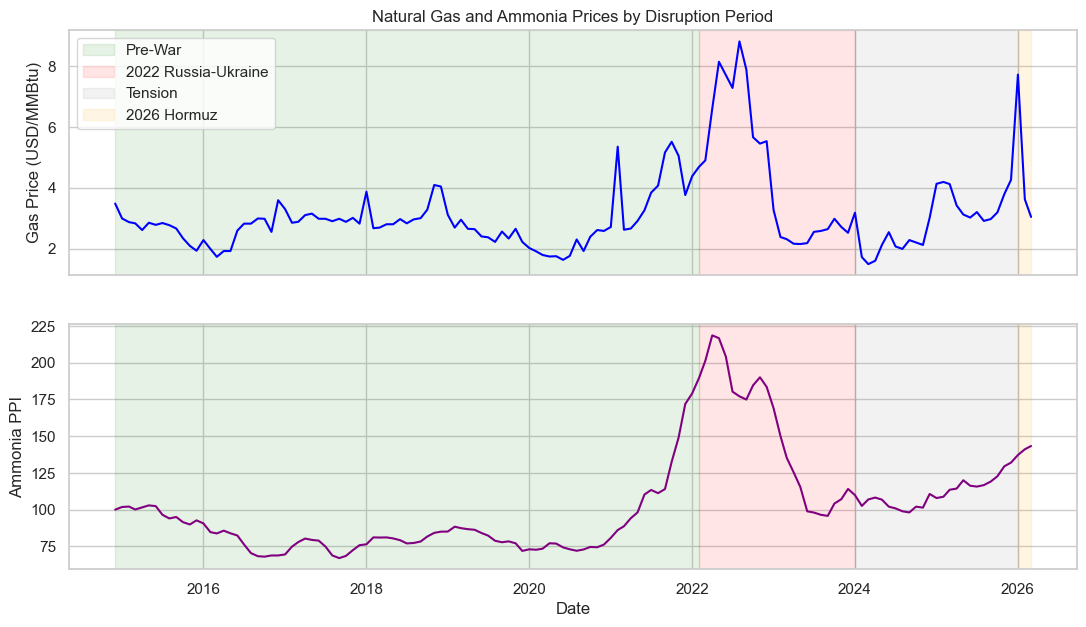

In [5]:
colors = ["green", "red", "gray", "orange"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(df["date"], df["gas_price"], color="blue")
ax1.axvspan(pre_start, ukraine_start, alpha=0.10, color="green", label="Pre-War")
ax1.axvspan(ukraine_start, pause_start, alpha=0.10, color="red", label="2022 Russia-Ukraine")
ax1.axvspan(pause_start, hormuz_start, alpha=0.10, color="gray", label="Tension")
ax1.axvspan(hormuz_start, end_date, alpha=0.10, color="orange", label="2026 Hormuz")
ax1.set_title("Natural Gas and Ammonia Prices by Disruption Period")
ax1.set_ylabel("Gas Price (USD/MMBtu)")
ax1.legend()


ax2.plot(df["date"], df["ammonia_ppi"], color="purple")
ax2.axvspan(pre_start, ukraine_start, alpha=0.10, color="green")
ax2.axvspan(ukraine_start, pause_start, alpha=0.10, color="red")
ax2.axvspan(pause_start, hormuz_start, alpha=0.10, color="gray")
ax2.axvspan(hormuz_start, end_date, alpha=0.10, color="orange")
ax2.set_ylabel("Ammonia PPI")
ax2.set_xlabel("Date")

plt.show()

### 4.1 Boxplots
Boxplots compare the full price distribution across periods, showing the spread, quartiles, and outliers rather than just the average.

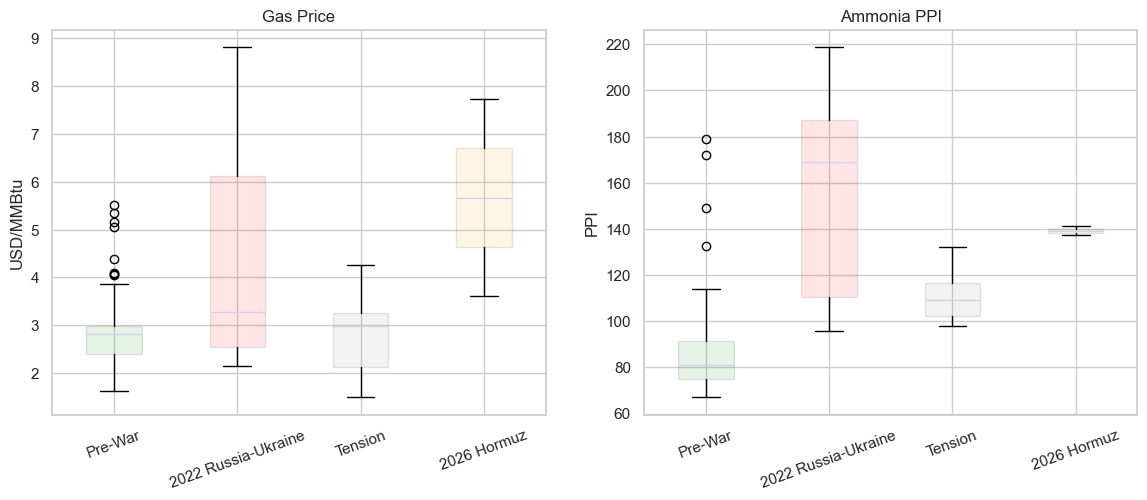

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (col, title, ylabel) in enumerate([
    ("gas_price","Gas Price","USD/MMBtu"),
    ("ammonia_ppi","Ammonia PPI","PPI")
]): 
    data = [
        df[(df["date"] >= start) & (df["date"] < end)][col]
        for start, end, color, label in periods
    ]
    labels = [
        label
        for start, end, color, label in periods
    ]
    bp = axes[i].boxplot(data, tick_labels=labels, patch_artist=True)
    for j, box in enumerate(bp["boxes"]):
        box.set_facecolor(colors[j])
        box.set_alpha(0.1)
    axes[i].set_title(title)
    axes[i].set_ylabel(ylabel)
    axes[i].tick_params(axis="x", rotation=20)
plt.show()

### 4.2 Period Changes vs Pre-war 
First, a full summary table is generated for each period, including mean, median, standard deviation, minimum, and maximum values.

From there, the pre-war period is used as the reference point, and percent changes in both natural gas and ammonia prices are calculated for each post-war period.

In [7]:
summary = df.groupby("period")[["gas_price","ammonia_ppi"]].agg(
    ["mean", "median", "std", "min", "max"]
).round(2)
summary
comp = df[df["period"] == "Pre-War"][["gas_price","ammonia_ppi"]].mean()
compare_periods = ["2022 Russia-Ukraine","Tension","2026 Hormuz"]
rows = []
for p in compare_periods:
    current = df[df["period"] == p][["gas_price","ammonia_ppi"]].mean()
    rows.append({
        "period": p,
        "gas_mean":current["gas_price"],
        "gas_pct_change": 100 * (current["gas_price"] -comp["gas_price"]) / comp["gas_price"],
        "ammonia_mean": current["ammonia_ppi"],
        "ammonia_pct_change":100 * (current["ammonia_ppi"] -comp["ammonia_ppi"]) /comp["ammonia_ppi"]
    })
change = pd.DataFrame(rows).round(2)
change

,period,gas_mean,gas_pct_change,ammonia_mean,ammonia_pct_change
0,2022 Russia-Ukraine,4.48,56.97,153.53,77.06
1,Tension,2.86,0.18,111.04,28.05
2,2026 Hormuz,4.79,67.90,140.54,62.07


## 5. Correlation 
If the 2022 shocks changed how ammonia prices moved, then the connection between ammonia and natural gas should be stronger after that point.

To test this, Pearson and Spearman correlations are calculated for the full dataset and for each separate period. This helps compare whether the ammonia and natural gas relationship changes under different market conditions.

The scatter plot gives a visual check of the same relationship. Each point represents one month, and the colors show which period the month belongs to. The trend line is included to show the overall direction between natural gas prices and ammonia prices.

Pearson r: 0.72 Pearson p-value: 0.0
Spearman r: 0.445 Spearman p-value: 0.0


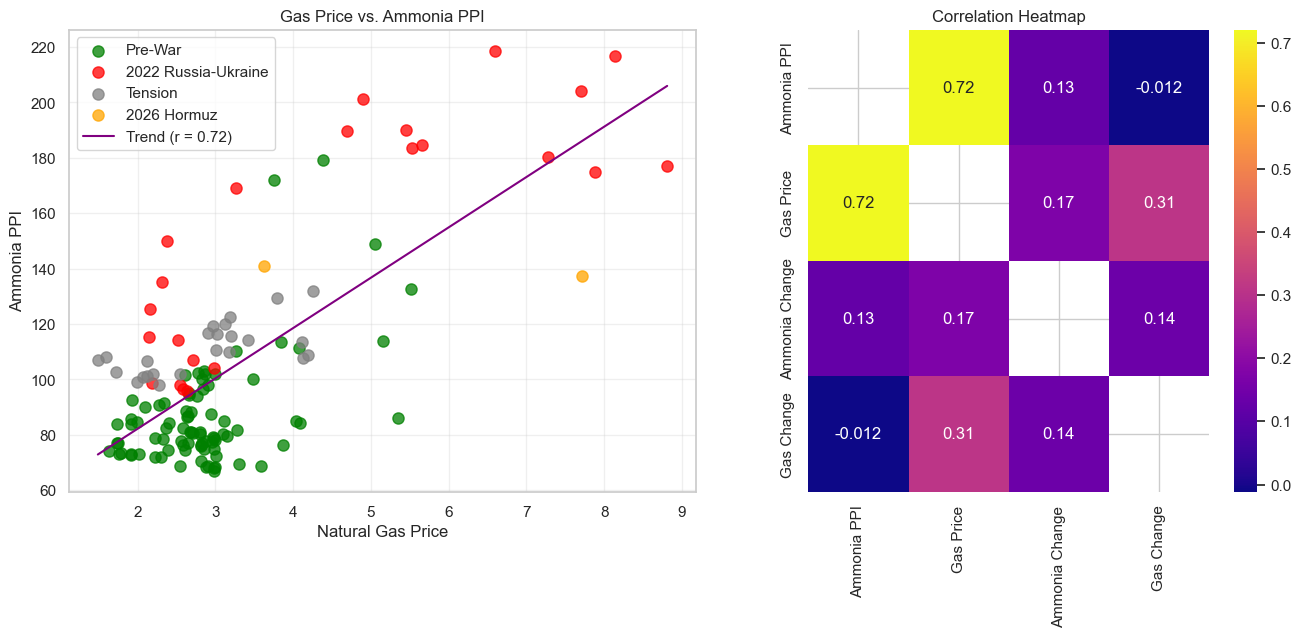

,Ammonia PPI,Gas Price,Ammonia Change,Gas Change
Ammonia PPI,1.000,0.720,0.125,-0.012
Gas Price,0.720,1.000,0.172,0.309
Ammonia Change,0.125,0.172,1.000,0.138
Gas Change,-0.012,0.309,0.138,1.000


In [8]:
corr_df = df.copy()
corr_df = corr_df.sort_values("date").reset_index(drop=True)
corr_df["gas_change"] = corr_df["gas_price"].pct_change() * 100
corr_df["ammonia_change"] = corr_df["ammonia_ppi"].pct_change() * 100
plot_df =corr_df.dropna(subset=["gas_price", "ammonia_ppi", "period"]).copy()


heatmap_df =corr_df.rename(columns={
    "ammonia_ppi":"Ammonia PPI",
    "gas_price": "Gas Price",
    "ammonia_change": "Ammonia Change",
    "gas_change": "Gas Change"
})
corr_cols = ["Ammonia PPI", "Gas Price", "Ammonia Change", "Gas Change"]
corr_matrix = heatmap_df[corr_cols].corr()


pearson_r, pearson_p = stats.pearsonr(plot_df["gas_price"],  plot_df["ammonia_ppi"])
print("Pearson r:", round(pearson_r, 3), "Pearson p-value:", round(pearson_p, 3))

spearman_r, spearman_p = stats.spearmanr(plot_df["gas_price"], plot_df["ammonia_ppi"])
print("Spearman r:", round(spearman_r, 3),"Spearman p-value:", round(spearman_p, 3))

slope,intercept = np.polyfit(plot_df["gas_price"],plot_df["ammonia_ppi"], 1)
x_line = np.linspace(plot_df["gas_price"].min(),plot_df["gas_price"].max(),100)
y_line =slope * x_line + intercept
period_colors = {"Pre-War": "green","2022 Russia-Ukraine": "red", "Tension": "gray", "2026 Hormuz": "orange"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),gridspec_kw={"width_ratios": [1.25, 1]})

# scatter plot
for start, end, color, label in periods:
    sub =plot_df[(plot_df["date"]>= start) & (plot_df["date"] <end)]
    ax1.scatter(sub["gas_price"], sub["ammonia_ppi"], s=65, alpha=0.75, color=color, label=label)
ax1.plot(x_line,y_line,color="purple",label=f"Trend (r = {pearson_r:.2f})")
ax1.set_title("Gas Price vs. Ammonia PPI")
ax1.set_xlabel("Natural Gas Price")
ax1.set_ylabel("Ammonia PPI")
ax1.grid(True, alpha=0.3)
ax1.legend()

# heatmap
mask = np.eye(len(corr_matrix), dtype=bool)
sns.heatmap(corr_matrix, annot=True, cmap="plasma", mask=mask)
ax2.set_title("Correlation Heatmap")
plt.show()

corr_matrix.round(3)

#### 5.1 Correlation Results
The scatter plot shows a clear positive relationship between natural gas prices and ammonia PPI. As natural gas prices increase, ammonia prices also tend to rise, with a correlation of r = 0.72. This suggests that natural gas price changes are strongly associated with the ammonia index.

The correlation heatmap confirms this relationship, showing the strongest correlation between gas price and ammonia PPI. However, the month to month change variables have much weaker correlations, meaning short-term price changes are less directly connected. Overall, the results indicate that natural gas prices are an important driver of ammonia prices, especially during disruption periods.

## 6. Regression

This section uses regression to test how strongly natural gas prices explain ammonia PPI during different market periods. The code first creates lagged gas price variables, including the current gas price, a 1 month lag, a 3 month lag, and a 6 month rolling average. These features are used because ammonia prices may not respond to gas prices immediately, so the lag variables help capture delayed effects. Also for the last part, the regression is run separately for each period defined as pre-war, 2022 Russia-Ukraine, tension, and 2026 Hormuz. 

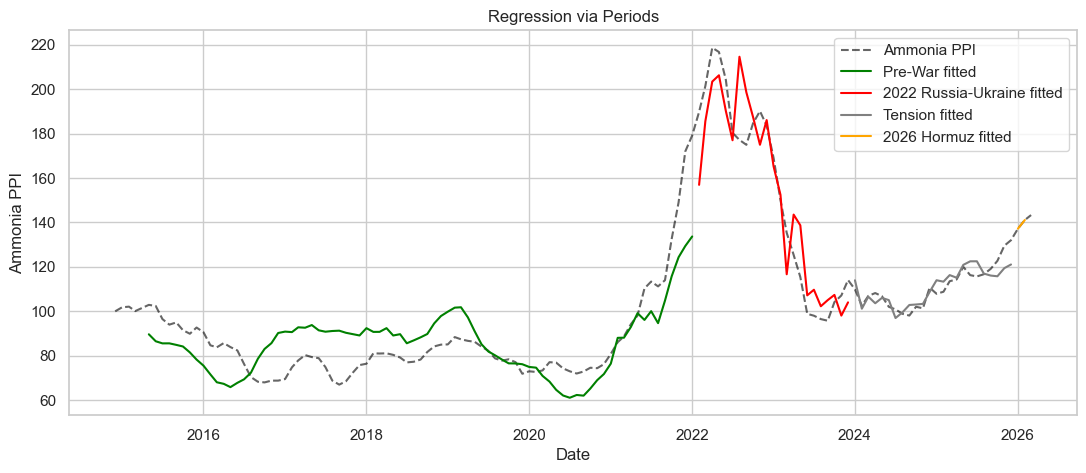

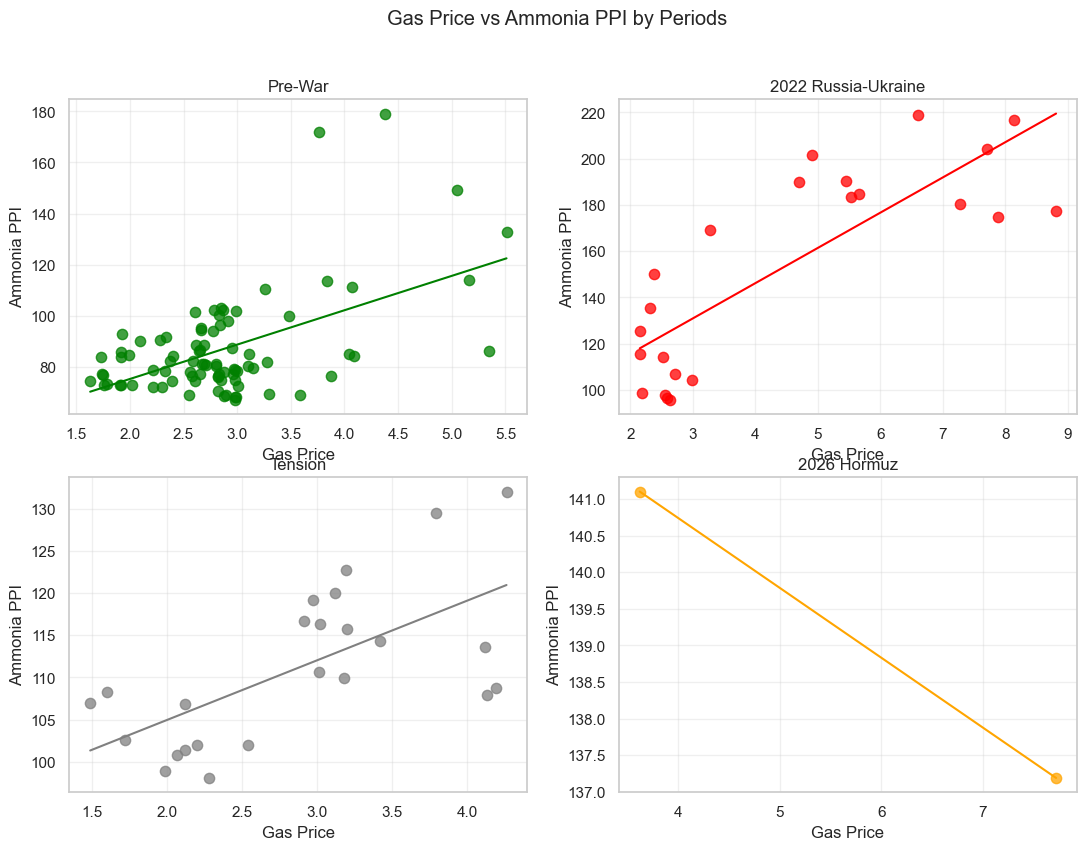

,period,months,slope,intercept,r2
0,Pre-War,86,13.46,48.29,0.28
1,2022 Russia-Ukraine,23,15.23,85.29,0.66
2,Tension,24,7.08,90.80,0.42
3,2026 Hormuz,2,-0.95,144.56,1.00


In [9]:

reg_df = df.copy()
reg_df = reg_df.sort_values("date").reset_index(drop=True)
reg_df["gas_lag1"] =reg_df["gas_price"].shift(1)
reg_df["gas_lag3"] =reg_df["gas_price"].shift(3)
reg_df["gas_roll6"] = reg_df["gas_price"].rolling(6).mean()
features = ["gas_price", "gas_lag1", "gas_lag3","gas_roll6"]

rows = []
models = {}
for start, end, color, label in periods:
    sub = reg_df[(reg_df["date"]>= start) &(reg_df["date"] < end)].copy()
    sub = sub.dropna(subset=features +["ammonia_ppi"]).copy()
    X = sub[features]
    y = sub["ammonia_ppi"]
    model = LinearRegression()
    model.fit(X, y)
    pred = model.predict(X)
    rows.append({
        "period": label,
        "n": len(sub),
        "intercept": model.intercept_,
        "coef_gas_price": model.coef_[0],
        "coef_gas_lag1": model.coef_[1],
        "coef_gas_lag3": model.coef_[2],
        "coef_gas_roll6": model.coef_[3],
        "mae": mean_absolute_error(y, pred),
        "rmse": np.sqrt(mean_squared_error(y, pred)),
        "r2": r2_score(y, pred)
    })
    
    models[label] = {
        "data": sub,
        "pred": pred,
        "color": color
    }
results_df = pd.DataFrame(rows).round(3)
results_df


fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df["date"],df["ammonia_ppi"], alpha = 0.6, linestyle = "--", color='black', label="Ammonia PPI")

for label in models:
    sub = models[label]["data"]
    pred = models[label]["pred"]
    color = models[label]["color"]
    ax.plot(sub["date"],pred, color= color, label =label + " fitted")

ax.set_title("Regression via Periods")
ax.set_xlabel("Date")
ax.set_ylabel("Ammonia PPI")
ax.legend()
plt.show()



data = df.copy()
data = data.sort_values("date")
data = data.dropna(subset=["gas_price", "ammonia_ppi"])

fig, axs = plt.subplots(2, 2, figsize=(13, 9))
axs = axs.flatten()
reg_info = []

for i, period in enumerate(periods):
    start = period[0]
    end = period[1]
    color = period[2]
    name = period[3]
    ax = axs[i]
    part = data[(data["date"] >= start) & (data["date"] < end)].copy()
    ax.set_title(name)
    ax.set_xlabel("Gas Price")
    ax.set_ylabel("Ammonia PPI")
    ax.grid(True, alpha=0.3)
    x = part[["gas_price"]]
    y = part["ammonia_ppi"]
    lr = LinearRegression()
    lr.fit(x, y)
    y_hat = lr.predict(x)
    r2 = r2_score(y, y_hat)
    reg_info.append({"period": name,"months":len(part), "slope": lr.coef_[0],"intercept":lr.intercept_,"r2":r2})
    ax.scatter(part["gas_price"],part["ammonia_ppi"],color=color,alpha=0.75,s=55)
    x_vals = np.linspace(part["gas_price"].min(),part["gas_price"].max(),100)
    x_vals_df = pd.DataFrame({"gas_price": x_vals})
    y_vals = lr.predict(x_vals_df)
    ax.plot(x_vals,y_vals,color=color)

fig.suptitle("Gas Price vs Ammonia PPI by Periods")
plt.show()

reg_table = pd.DataFrame(reg_info).round(2)
reg_table

#### 6.1 Regression Results
The results show that the relationship is not constant across periods. In the pre-war period, gas prices explain some ammonia prices, but the fit is weaker, with a r-squared of about 0.28. During the 2022 Russia-Ukraine period, the relationship becomes much stronger, with an r-squared of about 0.66. This suggests that during the disruption period, ammonia prices became more closely tied to natural gas prices. The tension period also shows a moderate relationship, with an r-squared of about 0.43. The 2026 Hormuz period shows an r-squared of 1.000, but this is not reliable because there is not enough data.

Overall, the regression results suggest that natural gas prices are an important piece of resource when it come to   ammonia PPI, but the strength of that relationship changes depending on the market period. The 2022 shock period shows the clearest connection, which supports the idea that major geopolitical disruptions can make ammonia prices more sensitive to energy market conditions.

## 7. K-means Clustering
This section uses K-means clustering to find different market regimes based on natural gas prices, ammonia PPI, and their monthly percentage changes. Since K-means needs the number of clusters to be chosen before running the model, silhouette scores are tested for k.

 k 2


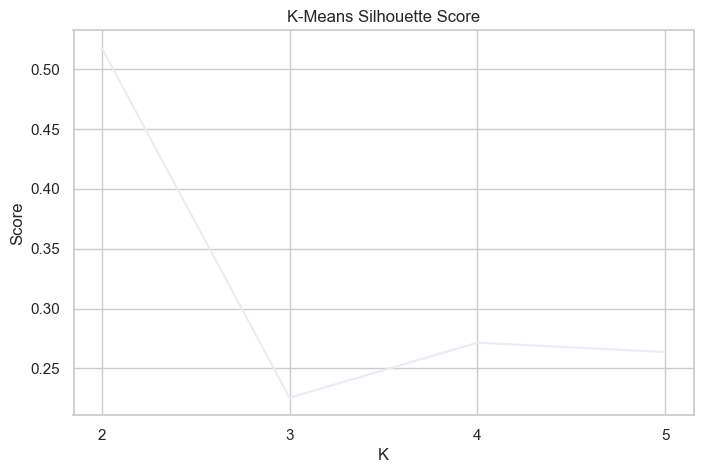

In [10]:
df = df.sort_values("date").reset_index(drop=True).copy()

df["gas_change"] =df["gas_price"].pct_change()
df["ammonia_change"] =df["ammonia_ppi"].pct_change()

cluster_features =["gas_price","ammonia_ppi", "gas_change", "ammonia_change"]
cluster_df =df.dropna(subset=cluster_features).copy()

X =cluster_df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
s_rows = []

for k in range(2, 6):
    kmeans =KMeans(n_clusters = k, random_state= 42,n_init=10)
    labels =kmeans.fit_predict(X_scaled)
    score =silhouette_score(X_scaled, labels)
    s_rows.append({"k": k,"silhouette_score": score})
s_df = pd.DataFrame(s_rows).round(4)
s_df

best_k = int(s_df.loc[s_df["silhouette_score"].idxmax(),"k"])
print(" k", best_k)

fig,ax =plt.subplots(figsize=(8, 5))
sns.lineplot(data=s_df,x="k",y="silhouette_score")
ax.set_title("K-Means Silhouette Score")
ax.set_xlabel("K")
ax.set_ylabel("Score")
ax.set_xticks(s_df["k"])
plt.show()

## 7.1 Silhouette Score
The silhouette score results show that k = 2 gives the best clustering performance, with a score of about 0.52. This indicates that the data is best separated into two main groups. After fitting the final K-means model, the clusters are examined over time to see whether they correspond to major market events.

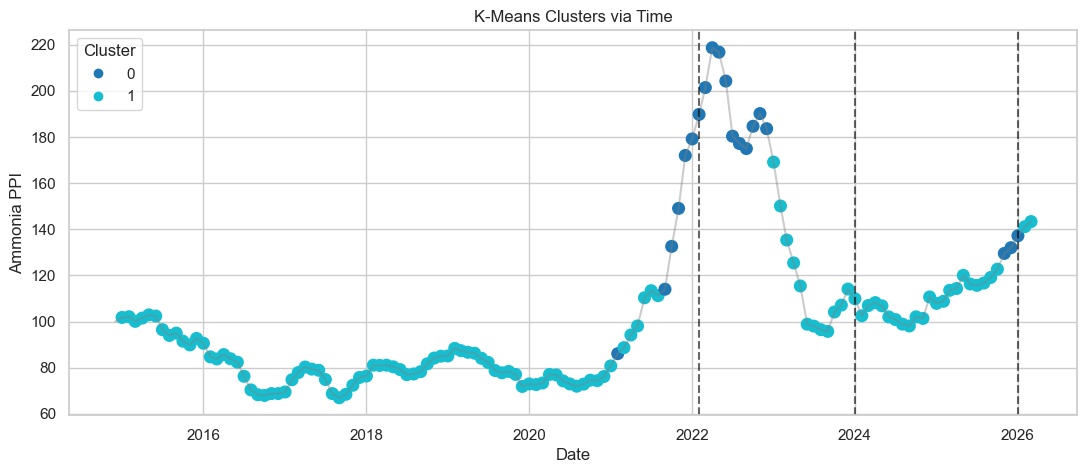

In [11]:
final_kmeans = KMeans(n_clusters=best_k,random_state=42,n_init=10)
cluster_df["cluster"] = final_kmeans.fit_predict(X_scaled)
df["cluster"] = pd.NA
df.loc[cluster_df.index, "cluster"] = cluster_df["cluster"]

cluster_summary = (
    cluster_df
    .groupby("cluster")
    .agg(months=("date","count"), start_date=("date", "min"),end_date=("date","max"), 
        avg_gas_price=("gas_price","mean"), avg_ammonia_ppi=("ammonia_ppi", "mean"),
        avg_gas_change=("gas_change", "mean"), avg_ammonia_change=("ammonia_change","mean")
    )
    .reset_index()
)
cluster_summary

fig, ax = plt.subplots(figsize=(13, 5))
scatter = ax.scatter(cluster_df["date"], cluster_df["ammonia_ppi"], c = cluster_df["cluster"], cmap = "tab10",s = 70)
ax.plot(df["date"], df["ammonia_ppi"], color = "gray", alpha = 0.4)
event_lines = [("Ukraine War Start", "ukraine_start"),("Pause Start", "pause_start"),("Hormuz Start", "hormuz_start")]

for label, var_name in event_lines:
    if var_name in globals():
        event_date = globals()[var_name]
        ax.axvline(event_date,color="black",linestyle="--", alpha = 0.6,)

ax.set_title(f"K-Means Clusters via Time")
ax.set_xlabel("Date")
ax.set_ylabel("Ammonia PPI")
legend = ax.legend(*scatter.legend_elements(), title = "Cluster")
plt.show()

#### 7.2 K-means Clustering Results
The timeline plot shows that one cluster captures the high price period around the 2022 Russia–Ukraine war, when ammonia prices rose. Most of the other months fall into the second cluster, which represents more typical market conditions. This suggests that K-means was able to separate the data into a normal periods and a disruption perionds without being told the different periods.

## 8. Anomaly Detection
This section looks for unusual monthly movements in natural gas prices and ammonia PPI. For each month, the return is compared using a z-score. If the absolute z-score is greater than 2, that month is flagged as an anomaly for either natural gas or ammonia.

Z-score anomalies: 26 of 136 months


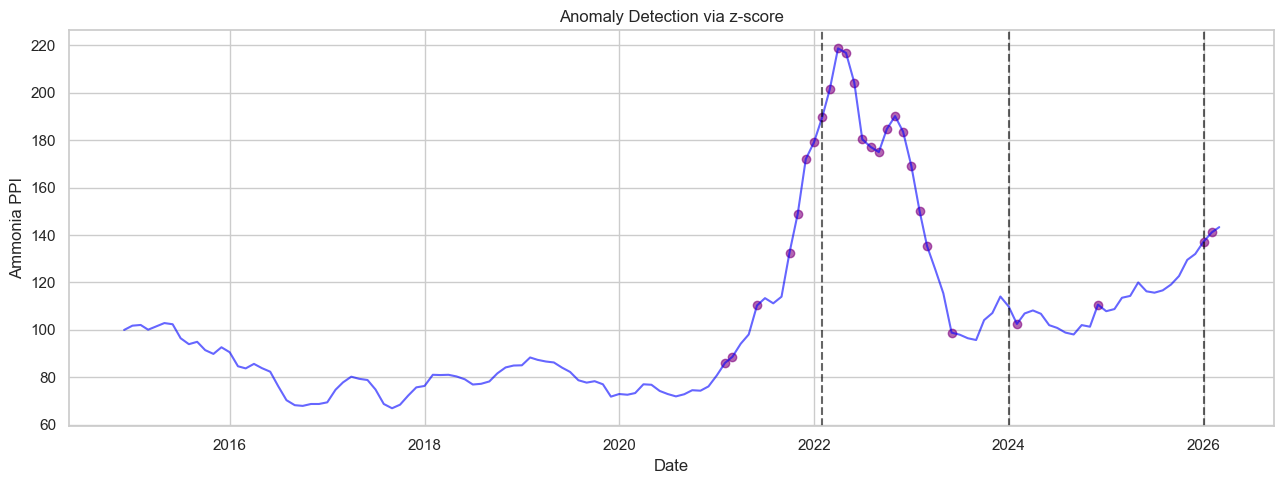

In [12]:
df["gas_ret"] = df["gas_price"].pct_change()
df["ppi_ret"] = df["ammonia_ppi"].pct_change()
cols = ["gas_price", "ammonia_ppi", "gas_ret", "ppi_ret"]

for col in cols:
    df[col + "_z"] = (df[col] - df[col].mean()) / df[col].std()

z_threshold = 2
df["anomaly"] = (
    (df[ "gas_price_z"].abs() > z_threshold) |
    (df["ammonia_ppi_z"].abs()> z_threshold) |
    (df[ "gas_ret_z"].abs() >z_threshold) |
    (df["ppi_ret_z"].abs() > z_threshold)
)

print("Z-score anomalies:",int(df["anomaly"].sum()),"of",len(df), "months")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df["date"], df["ammonia_ppi" ], color= 'blue',label="Ammonia PPI",alpha=0.6,)
anom = df[df["anomaly"]]
ax.scatter(anom["date"], anom["ammonia_ppi"],color="purple",alpha=0.6,label="Anomaly")

ax.axvline( ukraine_start, color="black",linestyle="--", alpha=0.6)
ax.axvline(pause_start, color="black", linestyle="--", alpha=0.6)
ax.axvline( hormuz_start, color="black", linestyle="--", alpha=0.6)

ax.set_title("Anomaly Detection via z-score")
ax.set_xlabel( "Date")
ax.set_ylabel("Ammonia PPI")


plt.tight_layout()
plt.show()

#### 8.1 Anomaly Detection Results
The anomaly detection results show that most of the unusual ammonia price movements happen around the 2022 Russia-Ukraine war period. The model flags several months during the sharp increase and peak in ammonia PPI, which suggests that this period was clearly different from normal market behavior.

Outside of the 2022 shock, there are only a few flagged points, including around the later tension and 2026 Hormuz periods. Overall, the results show that the biggest abnormal behavior in ammonia prices occurred during the 2022 price spike, supporting the idea that the war period created a major disruption in the ammonia market.

## 9. Green vs Traditional Haber-Bosch Ammonia
This section brings the analysis back to the main research question. One issue is that the traditional ammonia data is shown as a Producer Price Index, while the green ammonia costs are listed in dollars per ton. Since they are not in the same units, they have to be adjusted before comparing them.

To do this, the traditional ammonia PPI is converted into an estimated dollar-per-ton price. December 2014 is used as the starting point, where the PPI equals 100. That value is matched to a U.S. wholesale ammonia price of $550 per ton, and the rest of the PPI values are scaled from there.

This gives an estimated price path for traditional ammonia that can be shown on the same graph as the green ammonia cost range. A pivot table is also used to organize the green ammonia costs by plant type and operating setup, which makes the comparison easier to read.

Overall, this step shows whether green ammonia looks more competitive when traditional ammonia prices rise during energy or geopolitical shocks.

Competitive Months: 6


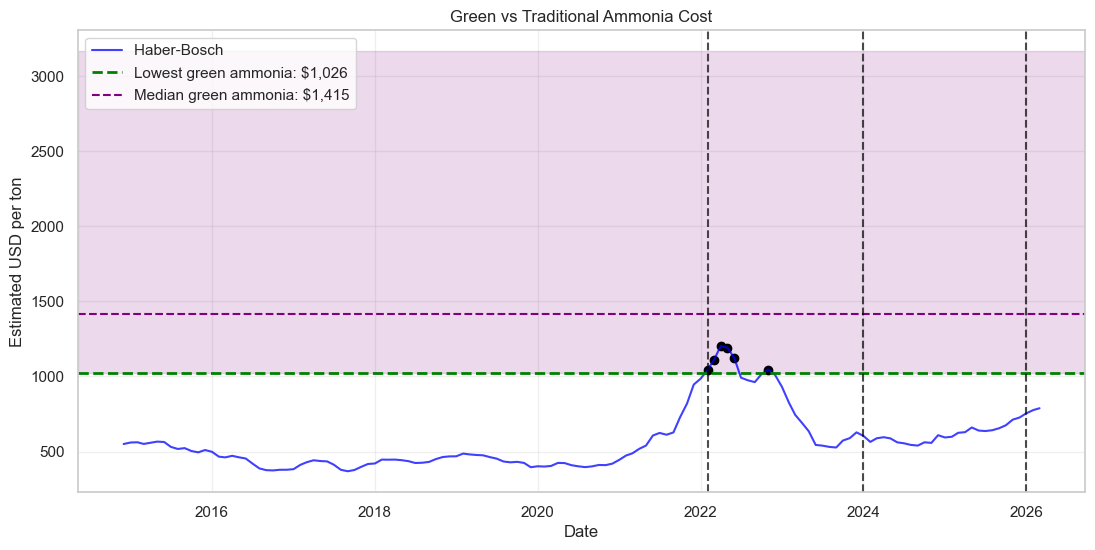

In [13]:
df = df.sort_values("date").reset_index(drop=True)
reference_price = 550
ppi_reference = df.loc[df["date"] == "2014-12-01", "ammonia_ppi"].iloc[0]
df["ammonia_usd_ton"] = df["ammonia_ppi"] * reference_price / ppi_reference

green_data = green_df.copy()
green_data["cost"] = pd.to_numeric(green_data["cost"], errors="coerce")
green_data = green_data.dropna(subset=["cost"])
green_data = green_data[green_data["config"].str.contains("100MW", na=False)]

green_low = green_data["cost"].min()
green_mid = green_data["cost"].median()
green_high = green_data["cost"].max()
competitive_months = df[df["ammonia_usd_ton"] >= green_low]

print("Competitive Months:", len(competitive_months))

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df["date"],df["ammonia_usd_ton"],color="blue",label="Haber-Bosch ",alpha= 0.75)
ax.axhspan(green_low,green_high, color="purple", alpha= 0.15,)
ax.axhline(green_low,color="green",linestyle="--",linewidth=2,label=f"Lowest green ammonia: ${green_low:,.0f}")
ax.axhline(green_mid, color="purple",linestyle="--",label=f"Median green ammonia: ${green_mid:,.0f}")
ax.scatter( competitive_months["date"], competitive_months["ammonia_usd_ton"], color="black",)

for event_date in [ukraine_start, pause_start, hormuz_start]:
    ax.axvline(event_date, color="black", linestyle="--", alpha=0.7)

ax.set_title("Green vs Traditional Ammonia Cost")
ax.set_xlabel("Date")
ax.set_ylabel("Estimated USD per ton")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

#### 9.1 Comparison Resutlts 
Traditional ammonia stays well below green ammonia costs for most of the period, but the gap closes during the 2022 spike. Prices briefly reach or exceed the lowest green ammonia level. Outside of these disruption periods, traditional ammonia remains cheaper.

## 10. Conclusions
Overall, the results show that ammonia prices changed after 2022. Ammonia PPI rose sharply after the Ukraine shock and increased again during the Hormuz period. Natural gas also became more closely connected to ammonia prices, especially during the 2022 disruption. The regression and clustering results support this because the strongest patterns show up during the same high price periods.

The green ammonia comparison shows that green ammonia is still not usually cheaper than traditional ammonia, but it becomes more competitive during crisis periods. This matters because all of the months where traditional ammonia reached the low end of green ammonia costs happened after 2022.

There are still limitations. The Hormuz period has very few months of data Because of that, the results should be treated as evidence of a possible shift.